<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [462]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
"""Ссылка на файлы https://drive.google.com/drive/folders/1ULrXnXkV_qEifd4SBOJ1ynGaCUl6I7E-?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto"""

'Ссылка на файлы https://drive.google.com/drive/folders/1ULrXnXkV_qEifd4SBOJ1ynGaCUl6I7E-?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto'

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [463]:
hh = pd.read_csv('hh_database.csv', sep=';', engine='python', on_bad_lines='skip')
print(hh.shape)

(44744, 12)


2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [464]:
print("ПЕРВЫЕ 5 СТРОК")
print(hh.head())


ПЕРВЫЕ 5 СТРОК
                                   Пол, возраст           ЗП  \
0    Мужчина ,  39 лет , родился 27 ноября 1979   29000 руб.   
1     Мужчина ,  60 лет , родился 20 марта 1959   40000 руб.   
2  Женщина ,  36 лет , родилась 12 августа 1982   20000 руб.   
3      Мужчина ,  38 лет , родился 25 июня 1980  100000 руб.   
4     Женщина ,  26 лет , родилась 3 марта 1993  140000 руб.   

                           Ищет работу на должность:  \
0                            Системный администратор   
1                               Технический писатель   
2                                           Оператор   
3  Веб-разработчик (HTML / CSS / JS / PHP / базы ...   
4                  Региональный менеджер по продажам   

                        Город, переезд, командировки  \
0  Советск (Калининградская область) , не готов к...   
1  Королев , не готов к переезду , готов к редким...   
2  Тверь , не готова к переезду , не готова к ком...   
3  Саратов , не готов к переезду , гото

3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

4. Обратите внимание на информацию о числе непустых значений.

In [465]:
hh.info()

<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Пол, возраст                     44744 non-null  str  
 1   ЗП                               44744 non-null  str  
 2   Ищет работу на должность:        44744 non-null  str  
 3   Город, переезд, командировки     44744 non-null  str  
 4   Занятость                        44744 non-null  str  
 5   График                           44744 non-null  str  
 6   Опыт работы                      44576 non-null  str  
 7   Последнее/нынешнее место работы  44743 non-null  str  
 8   Последняя/нынешняя должность     44742 non-null  str  
 9   Образование и ВУЗ                44744 non-null  str  
 10  Обновление резюме                44744 non-null  str  
 11  Авто                             44744 non-null  str  
dtypes: str(12)
memory usage: 4.1 MB


5. Выведите основную статистическую информацию о столбцах.


In [466]:
#print(hh.describe())
unique_experience = hh['Опыт работы'].nunique()
print(unique_experience)
top_job = hh['Ищет работу на должность:'].mode()[0]
print(f"Самая: {top_job}")

44413
Самая: Системный администратор


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [467]:
# Создаём lambda-функцию для определения уровня образования
hh['Образование'] = hh['Образование и ВУЗ'].apply(
    lambda x: (
        'высшее' if 'высшее' in ' '.join(str(x).split()[:3]).lower() and 'неоконченное' not in ' '.join(str(x).split()[:3]).lower()
        else 'неоконченное высшее' if 'неоконченное высшее' in ' '.join(str(x).split()[:3]).lower()
        else 'среднее специальное' if 'среднее специальное' in ' '.join(str(x).split()[:3]).lower() or 'среднее профессиональное' in ' '.join(str(x).split()[:3]).lower()
        else 'среднее' if 'среднее' in ' '.join(str(x).split()[:3]).lower() and 'специальное' not in ' '.join(str(x).split()[:3]).lower() and 'профессиональное' not in ' '.join(str(x).split()[:3]).lower()
        else None
    )
)

# Проверяем полученные категории
print("Уникальные категории образования:")
print(hh['Образование'].unique())
print("\nРаспределение по категориям:")
print(hh['Образование'].value_counts())

# Удаляем исходный признак
hh = hh.drop('Образование и ВУЗ', axis=1)

# Проверяем, что столбец удалён
print("\nСтолбцы после удаления (первые 15):")
print(hh.columns[:15].tolist())

Уникальные категории образования:
<StringArray>
['неоконченное высшее', 'высшее', 'среднее специальное', 'среднее']
Length: 4, dtype: str

Распределение по категориям:
Образование
высшее                 33863
среднее специальное     5765
неоконченное высшее     4557
среднее                  559
Name: count, dtype: int64

Столбцы после удаления (первые 15):
['Пол, возраст', 'ЗП', 'Ищет работу на должность:', 'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Обновление резюме', 'Авто', 'Образование']


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [468]:
# Функция для извлечения пола (М/Ж) из строки
# Формат: "Мужчина , 39 лет , родился 27 ноября 1979"
hh['Пол_новый'] = hh['Пол, возраст'].apply(
    lambda x: 'М' if 'Мужчина' in str(x) else 'Ж' if 'Женщина' in str(x) else None
)

# Функция для извлечения возраста как целого числа
hh['Возраст'] = hh['Пол, возраст'].apply(
    lambda x: int(str(x).split(',')[1].strip().split()[0]) if pd.notna(x) else None
)


# Переименовываем 'Пол_новый' в 'Пол'
hh = hh.rename(columns={'Пол_новый': 'Пол'})

# Удаляем исходный признак
hh = hh.drop('Пол, возраст', axis=1)

# 1. Процент женских резюме
female_count = (hh['Пол'] == 'Ж').sum()
total_count = hh['Пол'].notna().sum()
female_percent = (female_count / total_count) * 100
print(f"Процент женских резюме: {female_percent:.2f}%")

# 2. Средний возраст соискателей
avg_age = hh['Возраст'].mean()
print(f"Средний возраст соискателей: {avg_age:.1f} лет")

Процент женских резюме: 19.07%
Средний возраст соискателей: 32.2 лет


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [469]:
def extract_experience_months(text):
    if pd.isna(text):
        return None
    if not isinstance(text, str):
        return None
    if text.strip() == 'Не указано':
        return None

    text_lower = text.lower()

    # Ищем позицию "опыт работы"
    exp_pos = text_lower.find('опыт работы')
    if exp_pos == -1:
        return None

    # Берем текст после "опыт работы"
    remaining = text_lower[exp_pos + len('опыт работы'):].strip()

    # Разбиваем на слова
    words = remaining.split()

    years = 0
    months = 0

    if len(words) >= 2:
        # Первое слово - число
        if words[0].isdigit():
            first_num = int(words[0])

            # Смотрим на второе слово
            if words[1] in ['год', 'года', 'году', 'лет']:
                years = first_num
                # Если есть 3-е и 4-е слово - это может быть количество месяцев
                if len(words) >= 4 and words[2].isdigit() and words[3] in ['месяц', 'месяца', 'месяцев']:
                    months = int(words[2])
            elif words[1] in ['месяц', 'месяца', 'месяцев']:
                months = first_num

    if years == 0 and months == 0:
        return None

    return years * 12 + months

# Применяем
hh['Опыт работы (месяц)'] = hh['Опыт работы'].apply(extract_experience_months)

median_exp = hh['Опыт работы (месяц)'].median()
print(f"Медианный опыт работы (в месяцах): {median_exp:.0f}")

Медианный опыт работы (в месяцах): 100


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [470]:
# Список городов-миллионников
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград']

# Функция для извлечения города
def extract_city(text):
    if pd.isna(text):
        return None
    # Берём первую часть до запятой
    city_part = str(text).split(',')[0].strip()
    # Проверяем на Москву и Санкт-Петербург
    if city_part == 'Москва':
        return 'Москва'
    if city_part == 'Санкт-Петербург':
        return 'Санкт-Петербург'
    # Проверяем на город-миллионник
    if city_part in million_cities:
        return 'город-миллионник'
    return 'другие'

hh['Город'] = hh['Город, переезд, командировки'].apply(extract_city)

# Вычисляем процент соискателей из Санкт-Петербурга
spb_count = (hh['Город'] == 'Санкт-Петербург').sum()
total_count = hh['Город'].notna().sum()
spb_percent = (spb_count / total_count) * 100

print(f"Количество соискателей из Санкт-Петербурга: {spb_count}")
print(f"Общее количество соискателей: {total_count}")
print(f"Процент соискателей из Санкт-Петербурга: {spb_percent:.0f}%")

def extract_relocation(text):
    if pd.isna(text):
        return None
    parts = str(text).split(',')
    reloc_part = parts[-2].strip().lower()

    # Если есть явное указание на неготовность — False
    if 'не готов к переезду' in reloc_part or 'не готова к переезду' in reloc_part:
        return False
    # Во всех остальных случаях считаем, что готов
    return True

def extract_business_trip(text):
    if pd.isna(text):
        return None
    parts = str(text).split(',')
    last_part = parts[-1].strip().lower()

    # Если есть явное указание на неготовность — False
    if 'не готов к командировкам' in last_part or 'не готова к командировкам' in last_part:
        return False
    # Во всех остальных случаях (включая пропуски) считаем, что готов
    return True

# Применяем функции
hh['Готовность к переезду'] = hh['Город, переезд, командировки'].apply(extract_relocation)
hh['Готовность к командировкам'] = hh['Город, переезд, командировки'].apply(extract_business_trip)

# Процент готовых и к переездам, и к командировкам
both_ready = ((hh['Готовность к переезду'] == True) & (hh['Готовность к командировкам'] == True)).sum()
total_count = hh.shape[0]
print(f"\nКоличество готовых и к переездам, и к командировкам: {both_ready}")
print(f"Процент: {(both_ready / total_count * 100):.0f}%")

Количество соискателей из Санкт-Петербурга: 4937
Общее количество соискателей: 44744
Процент соискателей из Санкт-Петербурга: 11%

Количество готовых и к переездам, и к командировкам: 14334
Процент: 32%


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [471]:
# Список возможных категорий для Занятости
employment_categories = ['полная занятость', 'частичная занятость', 'проектная работа', 'волонтерство', 'стажировка']

# Список возможных категорий для Графика
schedule_categories = ['полный день', 'сменный график', 'гибкий график', 'удаленная работа', 'вахтовый метод']

# Функция для создания признаков-мигалок
def create_dummy_columns(df, source_column, categories):
    for category in categories:
        # Создаем столбец с именем категории
        df[category] = df[source_column].apply(
            lambda x: category in str(x).lower() if pd.notna(x) else False
        )

# Создаём признаки для Занятости
create_dummy_columns(hh, 'Занятость', employment_categories)

# Создаём признаки для Графика
create_dummy_columns(hh, 'График', schedule_categories)

# Подсчитываем количество True по каждой категории
print("Занятость:")
for cat in employment_categories:
    count = hh[cat].sum()
    print(f"  {cat}: {count}")

print("\nГрафик:")
for cat in schedule_categories:
    count = hh[cat].sum()
    print(f"  {cat}: {count}")

# Удаляем исходные столбцы
hh = hh.drop('Занятость', axis=1)
hh = hh.drop('График', axis=1)

# Количество людей, ищущих и проектную работу, и волонтерство
both_project_volunteer = ((hh['проектная работа'] == True) & (hh['волонтерство'] == True)).sum()
print(f"\nКоличество соискателей, ищущих и проектную работу, и волонтерство: {both_project_volunteer}")

# Количество людей, которые хотят работать и вахтовым методом, и с гибким графиком
both_rotational_flexible = ((hh['вахтовый метод'] == True) & (hh['гибкий график'] == True)).sum()
print(f"Количество соискателей, желающих работать вахтовым методом и с гибким графиком: {both_rotational_flexible}")

Занятость:
  полная занятость: 43284
  частичная занятость: 13136
  проектная работа: 8068
  волонтерство: 486
  стажировка: 2804

График:
  полный день: 41716
  сменный график: 12725
  гибкий график: 15584
  удаленная работа: 15022
  вахтовый метод: 3084

Количество соискателей, ищущих и проектную работу, и волонтерство: 436
Количество соискателей, желающих работать вахтовым методом и с гибким графиком: 2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [472]:

exchange_rates = pd.read_csv('ExchangeRates.csv', sep=',')

hh['date'] = pd.to_datetime(hh['Обновление резюме'], dayfirst=True).dt.normalize()
exchange_rates['date'] = pd.to_datetime(exchange_rates['date'], dayfirst=True).dt.normalize()

# СЛОВАРЬ
currency_dict = {
    'руб': 'RUB', 'рублей': 'RUB', 'рубля': 'RUB', 'руб.': 'RUB',
    'грн': 'UAH', 'гривна': 'UAH', 'гривен': 'UAH',
    'usd': 'USD', '$': 'USD',
    'eur': 'EUR', 'евро': 'EUR',
    'белруб': 'BYN', 'byn': 'BYN',
    'сом': 'KGS', 'kgs': 'KGS',
    'сум': 'UZS', 'uzs': 'UZS',
    'манат': 'AZN', 'azn': 'AZN',
    'тенге': 'KZT', 'kzt': 'KZT'
}

# ПАРСИНГ
def extract_salary_and_currency(text):
    if pd.isna(text):
        return np.nan, np.nan

    text = str(text).strip()
    parts = text.split()

    if not parts:
        return np.nan, np.nan

    # берём ПЕРВОЕ число (как требует курс!)
    salary_str = parts[0].replace(' ', '')

    try:
        salary = float(salary_str)
    except:
        salary = np.nan

    currency = None
    for part in parts[1:]:
        part_lower = part.lower()
        for key, value in currency_dict.items():
            if key in part_lower:
                currency = value
                break
        if currency:
            break

    return salary, currency

hh[['ЗП_число', 'ЗП_валюта']] = hh['ЗП'].apply(
    lambda x: pd.Series(extract_salary_and_currency(x))
)

# нормализация валют
hh['ЗП_валюта'] = hh['ЗП_валюта'].str.upper().str.strip()
exchange_rates['currency'] = exchange_rates['currency'].str.upper().str.strip()


hh = hh.merge(
    exchange_rates[['currency', 'date', 'close', 'proportion']],
    how='left',
    left_on=['ЗП_валюта', 'date'],
    right_on=['currency', 'date']
)

# ТОЛЬКО RUB
hh['close'] = hh['close'].fillna(1)
hh['proportion'] = hh['proportion'].fillna(1)


#  РАСЧЁТ
hh['ЗП (руб)'] = hh['ЗП_число'] * hh['close'] / hh['proportion']

# МЕДИАНА
salaries = hh['ЗП (руб)'].dropna()

q1 = salaries.quantile(0.01)
q99 = salaries.quantile(0.99)

salaries_filtered = salaries[(salaries >= q1) & (salaries <= q99)]

median_salary_thousands = int(round(salaries_filtered.median() / 1000))

print(f"Медианная зарплата в тысячах рублей: {median_salary_thousands}")

C:\Users\Klic\AppData\Local\Temp\ipykernel_20104\2997921283.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  exchange_rates['date'] = pd.to_datetime(exchange_rates['date'], dayfirst=True).dt.normalize()


Медианная зарплата в тысячах рублей: 59


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

=== ОСНОВНЫЕ СТАТИСТИКИ ВОЗРАСТА ===
Мода: 30
Медиана: 31.0
Среднее: 32.2
Минимум: 14
Максимум: 100
1-й перцентиль: 20.0
99-й перцентиль: 57.0


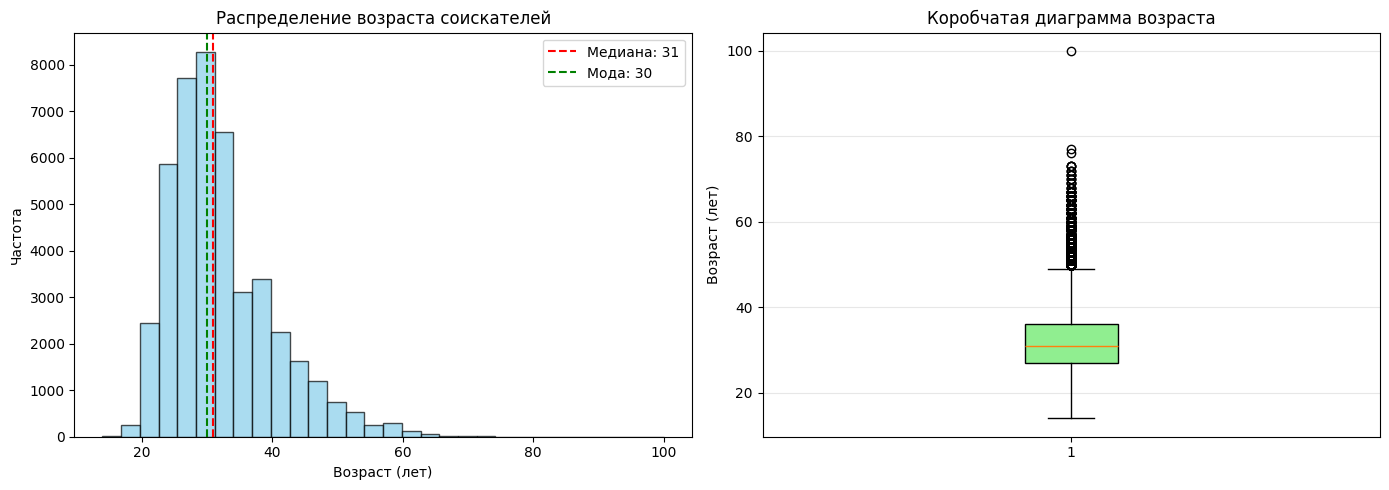

25-й перцентиль: 27
75-й перцентиль: 36
Межквартильный размах: 9
Нижняя граница: 14
Верхняя граница: 50
Модальное значение возраста: 30


In [473]:
import matplotlib.pyplot as plt
import seaborn as sns

# Убедимся, что возраст преобразован в числовой тип
hh['Возраст'] = pd.to_numeric(hh['Возраст'], errors='coerce')

# Удаляем пропуски для анализа
age_data = hh['Возраст'].dropna()

# ОСНОВНЫЕ СТАТИСТИКИ
print("=== ОСНОВНЫЕ СТАТИСТИКИ ВОЗРАСТА ===")
print(f"Мода: {age_data.mode().values[0]}")
print(f"Медиана: {age_data.median()}")
print(f"Среднее: {age_data.mean():.1f}")
print(f"Минимум: {age_data.min()}")
print(f"Максимум: {age_data.max()}")
print(f"1-й перцентиль: {age_data.quantile(0.01)}")
print(f"99-й перцентиль: {age_data.quantile(0.99)}")

# ПОСТРОЕНИЕ ГРАФИКОВ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(age_data, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение возраста соискателей')
axes[0].axvline(age_data.median(), color='red', linestyle='--', label=f'Медиана: {age_data.median():.0f}')
axes[0].axvline(age_data.mode().values[0], color='green', linestyle='--', label=f'Мода: {age_data.mode().values[0]:.0f}')
axes[0].legend()

# Коробчатая диаграмма (boxplot)
axes[1].boxplot(age_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_ylabel('Возраст (лет)')
axes[1].set_title('Коробчатая диаграмма возраста')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# КВАРТИЛИ И МЕЖКВАРТИЛЬНЫЙ РАЗМАХ
Q1 = age_data.quantile(0.25)
Q3 = age_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"25-й перцентиль: {Q1:.0f}")
print(f"75-й перцентиль: {Q3:.0f}")
print(f"Межквартильный размах: {IQR:.0f}")
print(f"Нижняя граница: {lower_bound:.0f}")
print(f"Верхняя граница: {upper_bound:.0f}")

hh['Возраст'] = pd.to_numeric(hh['Возраст'], errors='coerce')

# Вычисляем моду (наиболее часто встречающееся значение)
mode_values = hh['Возраст'].mode()

print(f"Модальное значение возраста: {mode_values[0]}")

Как мы видим по графику среднее вызраст соискателей 32 года, что соответсвует средену значению 32.2. основая ацдитория от 27 до 36 лет, что сооветсвует 25-ой перцентиль и 75-ой перцентиль. Выбросы составляют около 2-3% от всех данных (значения младше 14 лет и старше 50 лет)


2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

=== ОСНОВНЫЕ СТАТИСТИКИ ОПЫТА РАБОТЫ (в месяцах) ===
Мода: 81.0
Медиана: 100
Среднее: 114.4
Минимум: 1.0
Максимум: 1188.0
1-й перцентиль: 5
99-й перцентиль: 373
Стандартное отклонение: 79.0


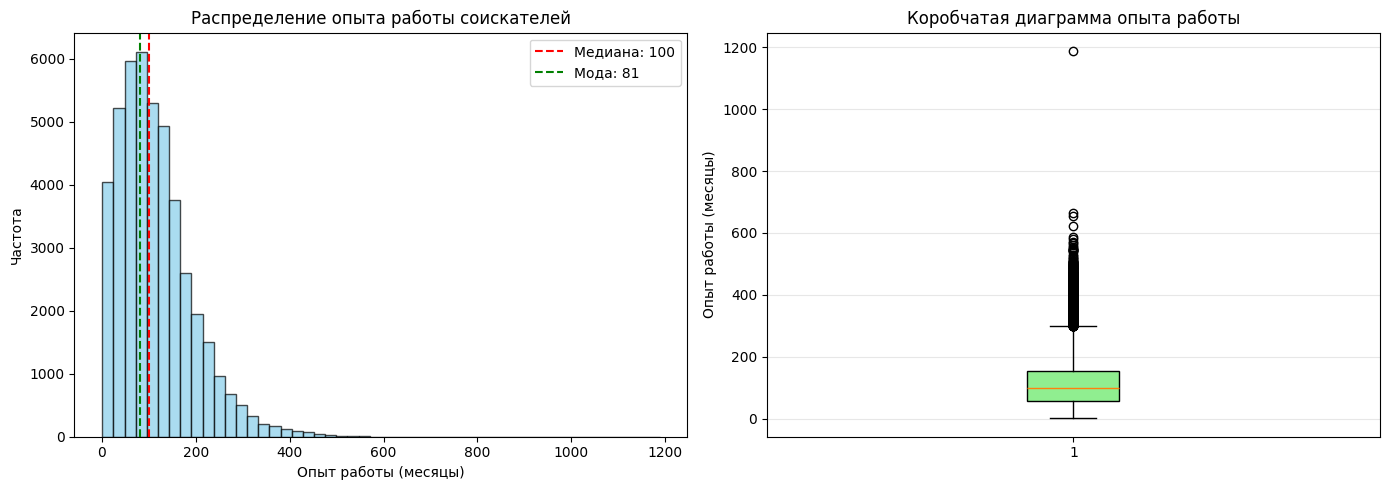


=== КВАРТИЛИ И ВЫБРОСЫ ===
25-й перцентиль: 57
75-й перцентиль: 154
Межквартильный размах: 97
Нижняя граница: -88
Верхняя граница: 300


In [474]:
# Убедимся, что опыт работы преобразован в числовой тип
hh['Опыт работы (месяц)'] = pd.to_numeric(hh['Опыт работы (месяц)'], errors='coerce')

# Удаляем пропуски для анализа
exp_data = hh['Опыт работы (месяц)'].dropna()

print("=== ОСНОВНЫЕ СТАТИСТИКИ ОПЫТА РАБОТЫ (в месяцах) ===")
print(f"Мода: {exp_data.mode().values[0]}")
print(f"Медиана: {exp_data.median():.0f}")
print(f"Среднее: {exp_data.mean():.1f}")
print(f"Минимум: {exp_data.min()}")
print(f"Максимум: {exp_data.max()}")
print(f"1-й перцентиль: {exp_data.quantile(0.01):.0f}")
print(f"99-й перцентиль: {exp_data.quantile(0.99):.0f}")
print(f"Стандартное отклонение: {exp_data.std():.1f}")

# ГРАФИК
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(exp_data, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Опыт работы (месяцы)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение опыта работы соискателей')
axes[0].axvline(exp_data.median(), color='red', linestyle='--', label=f'Медиана: {exp_data.median():.0f}')
axes[0].axvline(exp_data.mode().values[0], color='green', linestyle='--', label=f'Мода: {exp_data.mode().values[0]:.0f}')
axes[0].legend()

# Коробчатая диаграмма (boxplot)
axes[1].boxplot(exp_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_ylabel('Опыт работы (месяцы)')
axes[1].set_title('Коробчатая диаграмма опыта работы')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#КВАРТИЛИ И МЕЖКВАРТИЛЬНЫЙ РАЗМАХ
Q1 = exp_data.quantile(0.25)
Q3 = exp_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n=== КВАРТИЛИ И ВЫБРОСЫ ===")
print(f"25-й перцентиль: {Q1:.0f}")
print(f"75-й перцентиль: {Q3:.0f}")
print(f"Межквартильный размах: {IQR:.0f}")
print(f"Нижняя граница: {lower_bound:.0f}")
print(f"Верхняя граница: {upper_bound:.0f}")


Как мы видим на графике - средний опыт 9.5 лет (114 месяцев), 
* Мода = 81 месяц (6.7 лет) — наиболее часто встречающийся опыт
* 99% соискателей имеют опыт менее 373 месяцев (31 год)
* Аномалии: Опыт более 25 лет следует проверять на достоверность, возможно, это опытные специалисты, но могут быть и ошибки парсинга (как в случае с 1188 месяцами > 99 лет)
* 25-й перцентиль = 57 месяцев (4.75 года)
* 25-й перцентиль = 154 месяца (12.8 года)
* Большинство соискателей  имеют опыт от 4.8 до 12.8 лет


3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


Мода: 50000
Медиана: 58000
Среднее: 76289
Минимум: 1
Максимум: 24304876
1-й перцентиль: 3000
99-й перцентиль: 300000
Стандартное отклонение: 136028


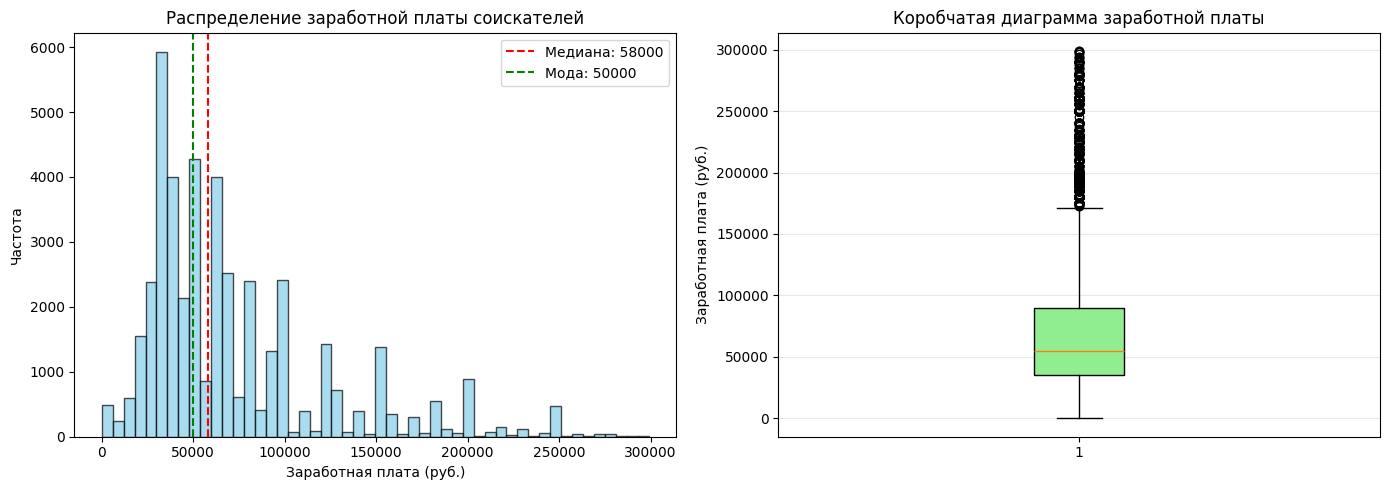

25-й перцентиль: 35721
75-й перцентиль: 95000
Межквартильный размах: 59279
Нижняя граница: -53197
Верхняя граница: 183918
Низкие выбросы (менее -53197 руб.): 0
Высокие выбросы (более 183918 руб.): 2780
Всего выбросов: 2780
Процент выбросов: 6.21%
Количество > 1млн: 5
Значения: [1750000.0, 2500000.0, 3000000.0, 7675224.0, 24304876.0]


In [475]:
# Убедимся, что ЗП_руб преобразован в числовой тип
hh['ЗП (руб)'] = pd.to_numeric(hh['ЗП (руб)'], errors='coerce')
salary_data = hh['ЗП (руб)'].dropna()

# Для анализа статистики удалим только нули и отрицательные значения (но не удаляем зарплаты > 1 млн)
salary_clean = salary_data[salary_data > 0]

print(f"Мода: {salary_clean.mode().values[0]:.0f}")
print(f"Медиана: {salary_clean.median():.0f}")
print(f"Среднее: {salary_clean.mean():.0f}")
print(f"Минимум: {salary_clean.min():.0f}")
print(f"Максимум: {salary_clean.max():.0f}")
print(f"1-й перцентиль: {salary_clean.quantile(0.01):.0f}")
print(f"99-й перцентиль: {salary_clean.quantile(0.99):.0f}")
print(f"Стандартное отклонение: {salary_clean.std():.0f}")

#ГРАФИК
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма (ограничим до 300000 для лучшей визуализации)
salary_vis = salary_clean[salary_clean < 300000]
axes[0].hist(salary_vis, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Заработная плата (руб.)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение заработной платы соискателей')
axes[0].axvline(salary_clean.median(), color='red', linestyle='--',
                label=f'Медиана: {salary_clean.median():.0f}')
axes[0].axvline(salary_clean.mode().values[0], color='green', linestyle='--',
                label=f'Мода: {salary_clean.mode().values[0]:.0f}')
axes[0].legend()

# Коробчатая диаграмма
axes[1].boxplot(salary_vis, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_ylabel('Заработная плата (руб.)')
axes[1].set_title('Коробчатая диаграмма заработной платы')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


#  КВАРТИЛИ И МЕЖКВАРТИЛЬНЫЙ РАЗМАХ
Q1 = salary_clean.quantile(0.25)
Q3 = salary_clean.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"25-й перцентиль: {Q1:.0f}")
print(f"75-й перцентиль: {Q3:.0f}")
print(f"Межквартильный размах: {IQR:.0f}")
print(f"Нижняя граница: {lower_bound:.0f}")
print(f"Верхняя граница: {upper_bound:.0f}")


#  ВЫБРОСЫ (АНАМАЛИИ)
outliers_low = salary_clean[salary_clean < lower_bound]
outliers_high = salary_clean[salary_clean > upper_bound]

print(f"Низкие выбросы (менее {lower_bound:.0f} руб.): {len(outliers_low)}")
print(f"Высокие выбросы (более {upper_bound:.0f} руб.): {len(outliers_high)}")
print(f"Всего выбросов: {len(outliers_low) + len(outliers_high)}")
print(f"Процент выбросов: {(len(outliers_low) + len(outliers_high))/len(salary_clean)*100:.2f}%")


# Используем исходные данные salary_data
high_salary_count = (salary_data > 1000000).sum()
print(f"Количество > 1млн: {high_salary_count}")

if high_salary_count > 0:
    high_salaries = salary_data[salary_data > 1000000].sort_values()
    print(f"Значения: {high_salaries.tolist()}")

* Мода = 50 000 рублей — наиболее часто запрашиваемая зарплата среди соискателей
* Предельные значения:
* Минимум: 1 рубль (вероятно ошибка )
* Максимум: 24 304 876 рублей (аномалия)
* Большинство соискателей запрашивают зарплату от 35 721 до 95 000 рублей, огруглим 40 000 - 100 000 рублей

Аномалии:
* Высокие выбросы (более 183 918 руб.): 2 780 соискателей
* Соискатели с зарплатой выше 1 млн руб.: всего 5 человек : 1 750 000 руб, 2 500 000 руб , 3 000 000 руб ,7 675 224 руб ,24 304 876 руб(явная ошибка)
* Есть и отрицательные значения

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

МЕДИАННА
высшее: 60,000 руб.
неоконченное высшее: 50,000 руб.
среднее: 40,000 руб.
среднее специальное: 40,000 руб.


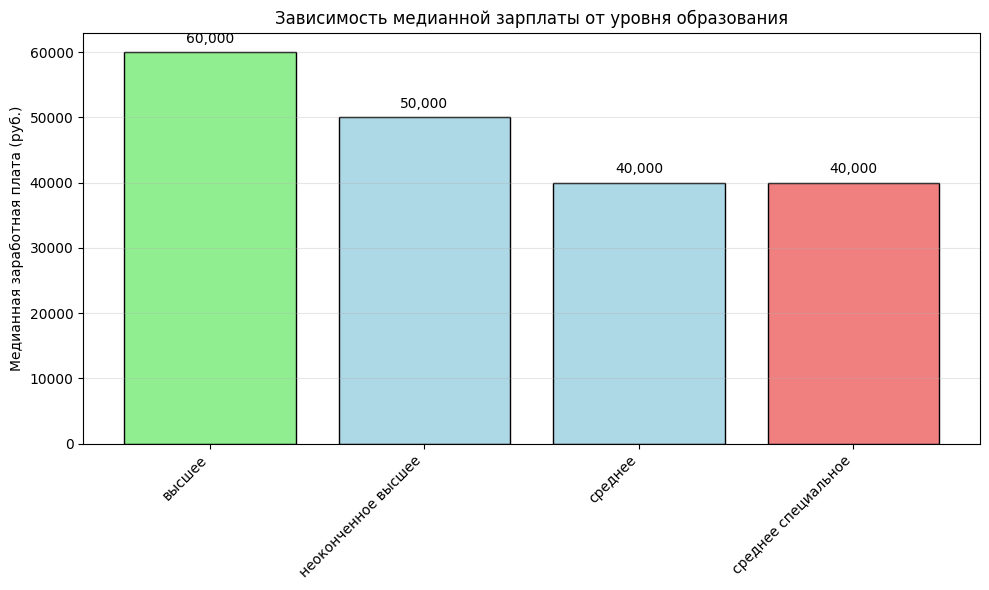


Количество соискателей по уровням образования:
высшее: 33863
неоконченное высшее: 4557
среднее: 559
среднее специальное: 5765


<Figure size 640x480 with 0 Axes>

In [476]:
# Фильтруем зарплаты меньше 1 млн рублей
salary_data = hh[hh['ЗП (руб)'] < 100000000].copy()

# Удаляем пропуски в образовании и зарплате
salary_data = salary_data.dropna(subset=['Образование', 'ЗП (руб)'])

# Группировка по образованию и расчет медианной зарплаты
education_salary = salary_data.groupby('Образование')['ЗП (руб)'].median().sort_values(ascending=False)

print("МЕДИАННА")
for edu, salary in education_salary.items():
    print(f"{edu}: {salary:,.0f} руб.")

# ДИАГРАММА
fig, ax = plt.subplots(figsize=(10, 6))

# Столбчатая диаграмма
colors = ['lightgreen' if i == 0 else 'lightcoral' if i == len(education_salary)-1 else 'lightblue'
          for i in range(len(education_salary))]
bars = ax.bar(range(len(education_salary)), education_salary.values, color=colors, edgecolor='black')
ax.set_xticks(range(len(education_salary)))
ax.set_xticklabels(education_salary.index, rotation=45, ha='right')
ax.set_ylabel('Медианная заработная плата (руб.)')
ax.set_title('Зависимость медианной зарплаты от уровня образования')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, education_salary.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА
print(f"\nКоличество соискателей по уровням образования:")
for edu in education_salary.index:
    count = salary_data[salary_data['Образование'] == edu].shape[0]
    print(f"{edu}: {count}")

plt.tight_layout()
plt.show()

Как мы видим по графику, что высшее образование имеет максимальный уровень медианы (60000 руб), среднее и среднее специальное самое низкий уровень(40000)
* высшее: 60,000 руб.
* неоконченное высшее: 50,000 руб.
* среднее: 40,000 руб.
* среднее специальное: 40,000 руб.

Действительно уровенб образования влияет на  уровень дохода, разница между высшим и средним 50% от дохода

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

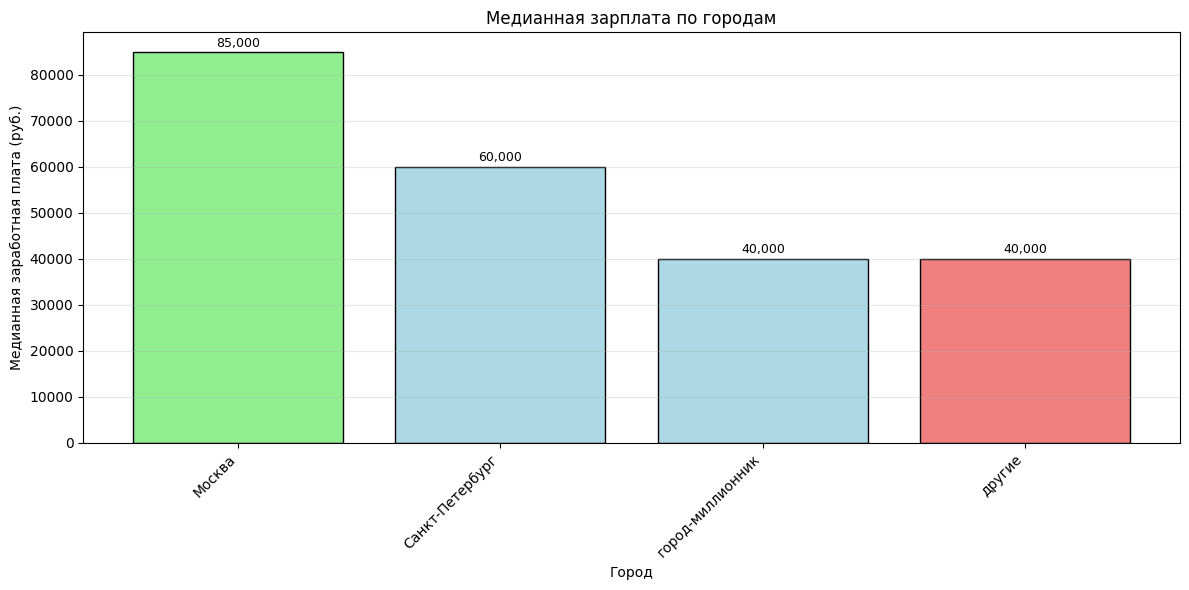


МЕДИАННАЯ ЗАРПЛАТА ПО ГОРОДАМ
Москва: 85,000 руб. (n=16621)
Санкт-Петербург: 60,000 руб. (n=4937)
город-миллионник: 40,000 руб. (n=7332)
другие: 40,000 руб. (n=15854)


In [477]:


# Фильтруем зарплаты меньше 1 млн рублей
salary_data = hh[hh['ЗП (руб)'] < 100000000].copy()

# Удаляем пропуски в городе и зарплате
salary_data = salary_data.dropna(subset=['Город', 'ЗП (руб)'])

# Группировка по городу и расчет медианной зарплаты
city_median = salary_data.groupby('Город')['ЗП (руб)'].median().sort_values(ascending=False)

# Цвета для столбцов
colors = ['lightgreen' if i == 0 else 'lightcoral' if i == len(city_median)-1 else 'lightblue'
          for i in range(len(city_median))]

# Построение столбчатой диаграммы
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(range(len(city_median)), city_median.values, color=colors, edgecolor='black')
ax.set_xticks(range(len(city_median)))
ax.set_xticklabels(city_median.index, rotation=45, ha='right')
ax.set_ylabel('Медианная заработная плата (руб.)')
ax.set_xlabel('Город')
ax.set_title('Медианная зарплата по городам')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, city_median.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Вывод статистики
print("\nМЕДИАННАЯ ЗАРПЛАТА ПО ГОРОДАМ")
for city, salary in city_median.items():
    count = salary_data[salary_data['Город'] == city].shape[0]
    print(f"{city}: {salary:,.0f} руб. (n={count})")

На графике мы видим:
* Москва лидирует с большим отрывом — медианная зарплата на 42% выше, чем в Санкт-Петербурге
* Санкт-Петербург занимает второе место, но отстает от Москвы на руб.
* Города-миллионники и другие города показывают одинаковую медианну (40 000 руб.)
* Разрыв между Москвой и регионами составляет 45 000 рублей (более чем в 2 раза)

Да, признак города является одним из самых важных факторов.
Москва превышает регионы более чем  в 2 раза, а Санкт-Петербург почта в 1.5 раза.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

Готов и к переезду, и к командировкам: 66,679 руб. (кол-во=14334)
Готов только к переезду: 50,000 руб. (кол-во=1691)
Готов только к командировкам: 60,000 руб. (кол-во=17382)
Не готов ни к переезду, ни к командировкам: 40,000 руб. (кол-во=11337)


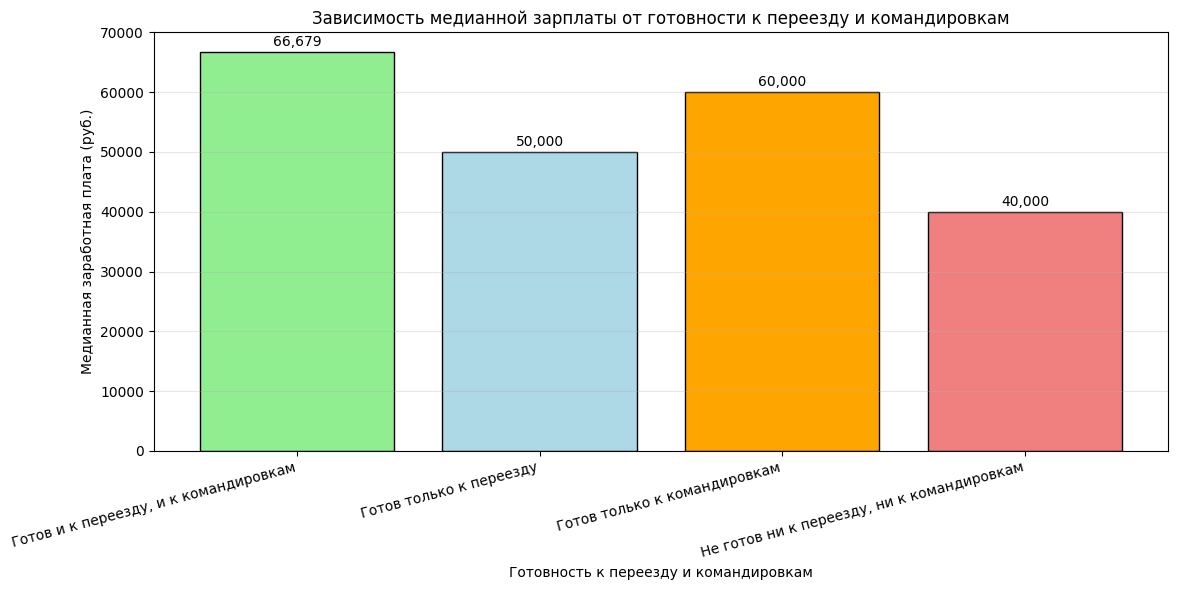

Медианная зарплата соискателей, готовых и к переезду, и к командировкам: 66,679 руб.
Ответ в тысячах рублей: 67


In [478]:
salary_data = salary_data.dropna(subset=['Готовность к переезду', 'Готовность к командировкам', 'ЗП (руб)'])

# Создаем комбинированный признак
def get_combination(row):
    reloc = row['Готовность к переезду']
    trip = row['Готовность к командировкам']
    if reloc and trip:
        return 'Готов и к переезду, и к командировкам'
    elif reloc and not trip:
        return 'Готов только к переезду'
    elif not reloc and trip:
        return 'Готов только к командировкам'
    else:
        return 'Не готов ни к переезду, ни к командировкам'

salary_data['Комбинация'] = salary_data.apply(get_combination, axis=1)

# Расчет медианной зарплаты по комбинациям
combination_order = ['Готов и к переезду, и к командировкам',
                      'Готов только к переезду',
                      'Готов только к командировкам',
                      'Не готов ни к переезду, ни к командировкам']

median_salaries = []
for combo in combination_order:
    median = salary_data[salary_data['Комбинация'] == combo]['ЗП (руб)'].median()
    median_salaries.append(median)
    count = len(salary_data[salary_data['Комбинация'] == combo])
    print(f"{combo}: {median:,.0f} руб. (кол-во={count})")

# Построение многоуровневой столбчатой диаграммы
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['lightgreen', 'lightblue', 'orange', 'lightcoral']
bars = ax.bar(range(len(combination_order)), median_salaries, color=colors, edgecolor='black')

ax.set_xticks(range(len(combination_order)))
ax.set_xticklabels(combination_order, rotation=15, ha='right')
ax.set_ylabel('Медианная заработная плата (руб.)')
ax.set_xlabel('Готовность к переезду и командировкам')
ax.set_title('Зависимость медианной зарплаты от готовности к переезду и командировкам')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, median_salaries):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Ответ на вопрос
both_ready_median = salary_data[salary_data['Комбинация'] == 'Готов и к переезду, и к командировкам']['ЗП (руб)'].median()
both_ready_thousands = int(round(both_ready_median / 1000))
print(f"Медианная зарплата соискателей, готовых и к переезду, и к командировкам: {both_ready_median:,.0f} руб.")
print(f"Ответ в тысячах рублей: {both_ready_thousands}")

Мы видим по диаграмме:
* Признаки готовности к переезду и командировкам очень важны — разница между крайними категориями составляет 65%
* Готовность к командировкам — более значимый фактор, чем готовность к переезду
Готовность к командировкам ценится выше, чем готовность к переезду:
* Только командировки: 60 000 руб.
* Только переезд: 50 000 руб.
* Разница: 10 000 рублей в пользу командировок

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

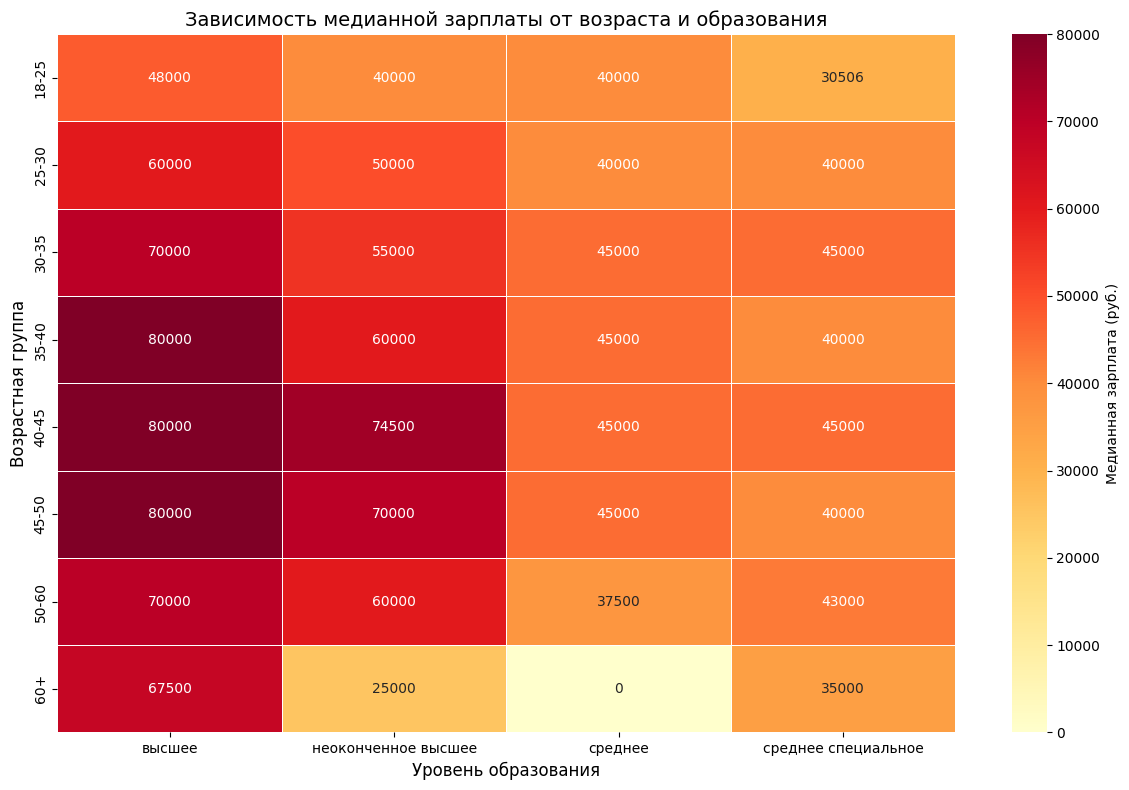

высшее:
  Начальная (18-25 лет): 48,000 руб.
  Пиковая (50-60 лет): 70,000 руб.
неоконченное высшее:
  Начальная (18-25 лет): 40,000 руб.
  Пиковая (50-60 лет): 60,000 руб.
среднее:
  Начальная (18-25 лет): 40,000 руб.
  Пиковая (50-60 лет): 37,500 руб.
среднее специальное:
  Начальная (18-25 лет): 30,506 руб.
  Пиковая (50-60 лет): 43,000 руб.


In [479]:


# Удаляем пропуски
salary_data = salary_data.dropna(subset=['Возраст', 'Образование', 'ЗП (руб)'])

# Создаем возрастные группы
salary_data['Возрастная группа'] = pd.cut(salary_data['Возраст'],
                                           bins=[18, 25, 30, 35, 40, 45, 50, 60, 100],
                                           labels=['18-25', '25-30', '30-35', '35-40',
                                                   '40-45', '45-50', '50-60', '60+'])

# Сводная таблица: медианная зарплата по возрастам и образованию
pivot_table = salary_data.pivot_table(
    values='ЗП (руб)',
    index='Возрастная группа',
    columns='Образование',
    aggfunc='median'
)

# Заполняем NaN для наглядности
pivot_table = pivot_table.fillna(0)



# ТЕПЛОВАЯ КАРТА
fig, ax = plt.subplots(figsize=(12, 8))

# Создаем тепловую карту
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Медианная зарплата (руб.)'})

ax.set_title('Зависимость медианной зарплаты от возраста и образования', fontsize=14)
ax.set_xlabel('Уровень образования', fontsize=12)
ax.set_ylabel('Возрастная группа', fontsize=12)

plt.tight_layout()
plt.show()

growth_rates = {}
for edu in pivot_table.columns:
    if edu != 0:
        young_salary = pivot_table.loc['18-25', edu]
        old_salary = pivot_table.loc['50-60', edu]
        if young_salary > 0:
            growth = ((old_salary - young_salary) / young_salary) * 100
            growth_rates[edu] = growth
            print(f"{edu}:")
            print(f"  Начальная (18-25 лет): {young_salary:,.0f} руб.")
            print(f"  Пиковая (50-60 лет): {old_salary:,.0f} руб.")


Мы видим на тепловой карте:
* С ростом возраста зарплата увеличивается для всех уровней образования
* Высшее образование показывает наивысшие зарплаты во всех возрастных группах
* Среднее образование — самые низкие показатели

Самый быстрый карьерный рост:
Высшее образование :
Начальная зарплата (18-25 лет): 48 000 руб.
Пиковая зарплата (40-45 лет): 80 000 руб.
Разница - 80%
У других видов образований показатель ниже

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

Всего точек для анализа: 44574


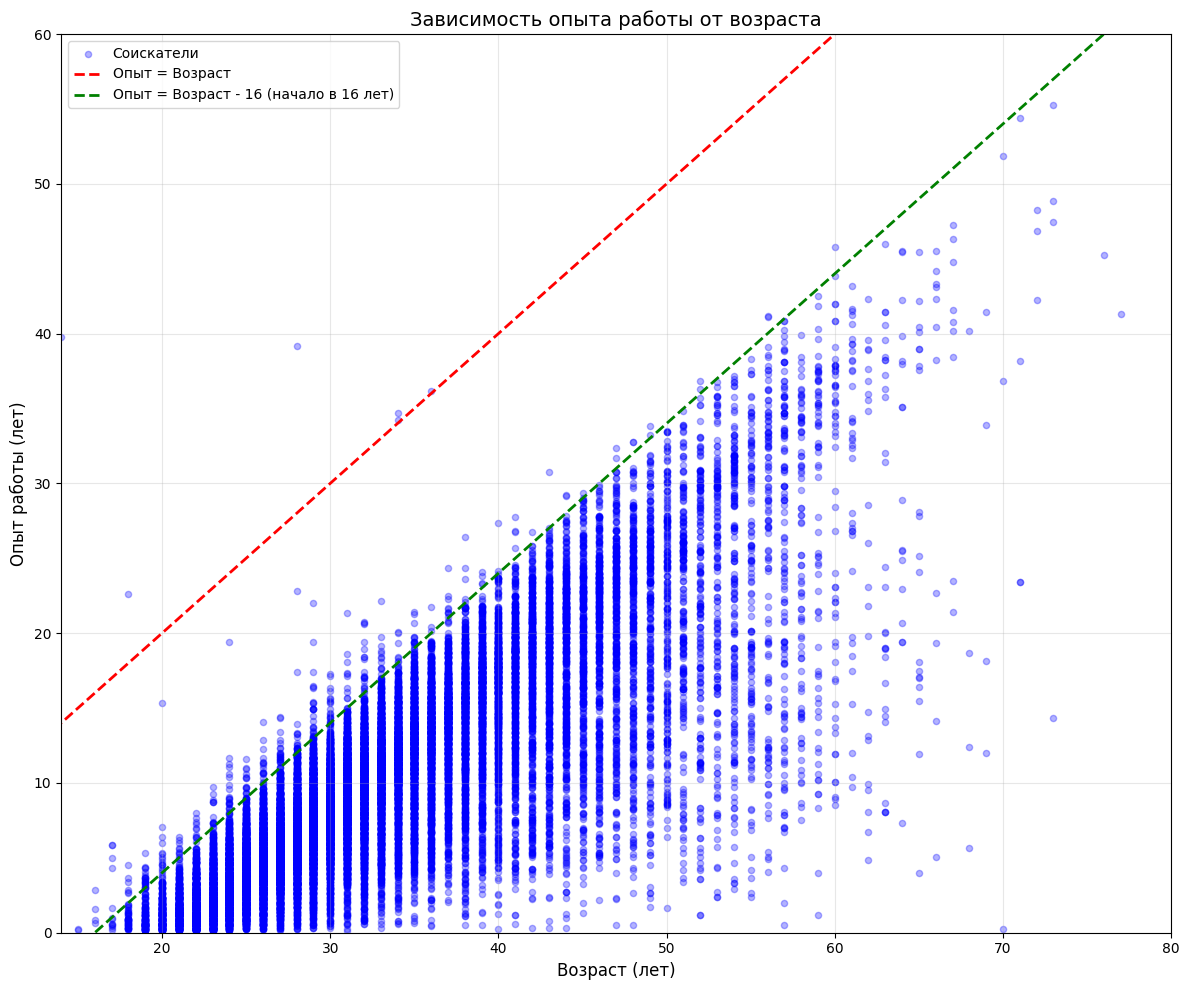

Количество точек: 7
Процент от всех точек: 0.02%
Минимальный опыт при максимальном возрасте: 2.5 лет
Максимальный опыт при минимальном возрасте: 39.8 лет

Примеры аномалий (первые 10):
  Возраст: 14 лет, Опыт: 39.8 лет (477 мес.)
  Возраст: 18 лет, Опыт: 22.6 лет (271 мес.)
  Возраст: 28 лет, Опыт: 39.2 лет (470 мес.)
  Возраст: 34 лет, Опыт: 34.7 лет (416 мес.)
  Возраст: 34 лет, Опыт: 34.2 лет (411 мес.)
  Возраст: 36 лет, Опыт: 36.2 лет (434 мес.)
  Возраст: 48 лет, Опыт: 99.0 лет (1188 мес.)


In [480]:

hh['Опыт работы (год)'] = hh['Опыт работы (месяц)'] / 12

# Удаляем пропуски и аномалии (опыт > возраст не может быть, но оставим для анализа)
data = hh.dropna(subset=['Возраст', 'Опыт работы (год)']).copy()

print(f"Всего точек для анализа: {len(data)}")


# ДИАГРАММA
fig, ax = plt.subplots(figsize=(12, 10))

# Диаграмма рассеяния
ax.scatter(data['Возраст'], data['Опыт работы (год)'],
           alpha=0.3, s=20, c='blue', label='Соискатели')

# Прямая опыт = возраст (x=y)
x_line = np.linspace(0, 100, 100)
y_line = x_line
ax.plot(x_line, y_line, 'r--', linewidth=2, label='Опыт = Возраст')

# Прямая опыт = возраст - 16 (начало карьеры в 16 лет)
y_line2 = x_line - 16
ax.plot(x_line, y_line2, 'g--', linewidth=2, label='Опыт = Возраст - 16 (начало в 16 лет)')

ax.set_xlabel('Возраст (лет)', fontsize=12)
ax.set_ylabel('Опыт работы (лет)', fontsize=12)
ax.set_title('Зависимость опыта работы от возраста', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(14, 80)
ax.set_ylim(0, 60)

plt.tight_layout()
plt.show()

# Точки лежат строго выше прямой, если опыт > возраст
points_above = data[data['Опыт работы (год)'] > data['Возраст']]

print(f"Количество точек: {len(points_above)}")
print(f"Процент от всех точек: {len(points_above)/len(data)*100:.2f}%")

print(f"Минимальный опыт при максимальном возрасте: {data[data['Возраст'] > 70]['Опыт работы (год)'].min():.1f} лет")
print(f"Максимальный опыт при минимальном возрасте: {data[data['Возраст'] < 20]['Опыт работы (год)'].max():.1f} лет")

# Показываем первые 10 аномалий
if len(points_above) > 0:
    print(f"\nПримеры аномалий (первые 10):")
    anomalies_sample = points_above.nsmallest(10, 'Возраст')[['Возраст', 'Опыт работы (год)', 'Опыт работы (месяц)']]
    for idx, row in anomalies_sample.iterrows():
        print(f"  Возраст: {row['Возраст']:.0f} лет, Опыт: {row['Опыт работы (год)']:.1f} лет "
              f"({row['Опыт работы (месяц)']:.0f} мес.)")
hh = hh.drop(columns=['Опыт работы (год)'])

Как мы видим на графике:
Всего 7 аномалий из 44 574 точек
Подавляющее большинство соискателей указали реалистичный опыт работы

Мы видим на графике:
* Всего 7 аномалий из 44 574 точек — очень хороший показатель
* Большинство соискателей указали реалистичный опыт работы
Разброс опыта при одном возрасте:
* Молодые специалисты (20-30 лет) - разброс небольшой
* Опытные специалисты (40-60 лет)- разброс больше
Аномалии скорее всего связана с опечаткой или преднамеренной дезинформацией

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


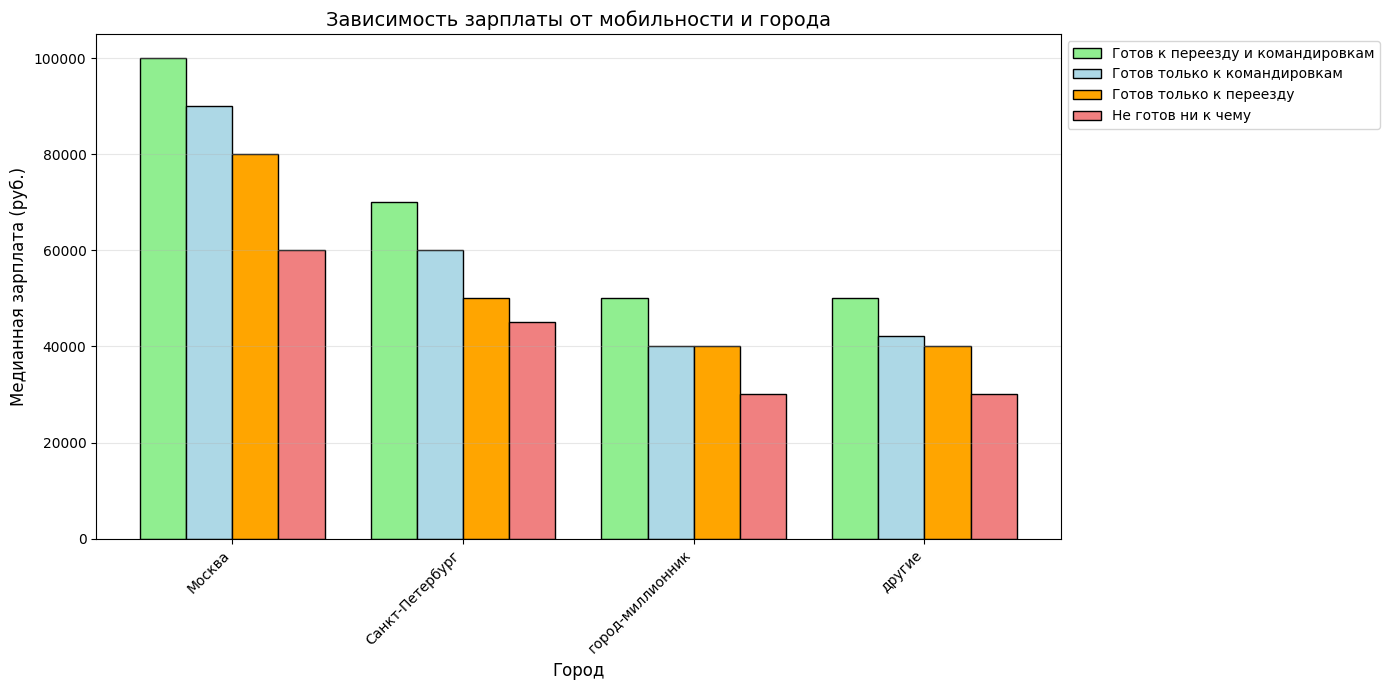

В Москве надбавка за мобильность максимальна:
   - Готов к переезду и командировкам: 100,000 руб.
   - Не готов ни к чему: 60,000 руб.
   - Разница: 40,000 руб.


In [481]:
salary_data = salary_data.dropna(subset=['Город', 'Готовность к переезду', 'Готовность к командировкам', 'ЗП (руб)'])

# Создаем комбинированный признак
def get_mobility_type(row):
    reloc = row['Готовность к переезду']
    trip = row['Готовность к командировкам']
    if reloc and trip:
        return 'Готов к переезду и командировкам'
    elif reloc and not trip:
        return 'Готов только к переезду'
    elif not reloc and trip:
        return 'Готов только к командировкам'
    else:
        return 'Не готов ни к чему'

salary_data['Мобильность'] = salary_data.apply(get_mobility_type, axis=1)

# Группировка по городу и мобильности
pivot_mobility = salary_data.pivot_table(
    values='ЗП (руб)',
    index='Город',
    columns='Мобильность',
    aggfunc='median'
).fillna(0)

# Порядок городов по зарплате
city_order = salary_data.groupby('Город')['ЗП (руб)'].median().sort_values(ascending=False).index

# Построение grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(city_order))
width = 0.2
mobility_types = ['Готов к переезду и командировкам', 'Готов только к командировкам',
                  'Готов только к переезду', 'Не готов ни к чему']
colors = ['lightgreen', 'lightblue', 'orange', 'lightcoral']

for i, (mobility, color) in enumerate(zip(mobility_types, colors)):
    values = [pivot_mobility.loc[city, mobility] if city in pivot_mobility.index else 0 for city in city_order]
    ax.bar(x + i*width, values, width, label=mobility, color=color, edgecolor='black')

ax.set_xlabel('Город', fontsize=12)
ax.set_ylabel('Медианная зарплата (руб.)', fontsize=12)
ax.set_title('Зависимость зарплаты от мобильности и города', fontsize=14)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(city_order, rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("В Москве надбавка за мобильность максимальна:")
print(f"   - Готов к переезду и командировкам: {pivot_mobility.loc['Москва', 'Готов к переезду и командировкам']:,.0f} руб.")
print(f"   - Не готов ни к чему: {pivot_mobility.loc['Москва', 'Не готов ни к чему']:,.0f} руб.")
print(f"   - Разница: {pivot_mobility.loc['Москва', 'Готов к переезду и командировкам'] - pivot_mobility.loc['Москва', 'Не готов ни к чему']:,.0f} руб.")


Мы видим на графике:
* Мобильность значительно увеличивает зарплатные ожидания
* Эффект сильнее в Москве (до 40 000 руб.) и слабее в регионах
* Готовность к командировкам ценится выше, чем готовность к переезду (кроме город - миллионик)
* Работодатели готовы платить премию за гибкость и готовность к разъездной работе

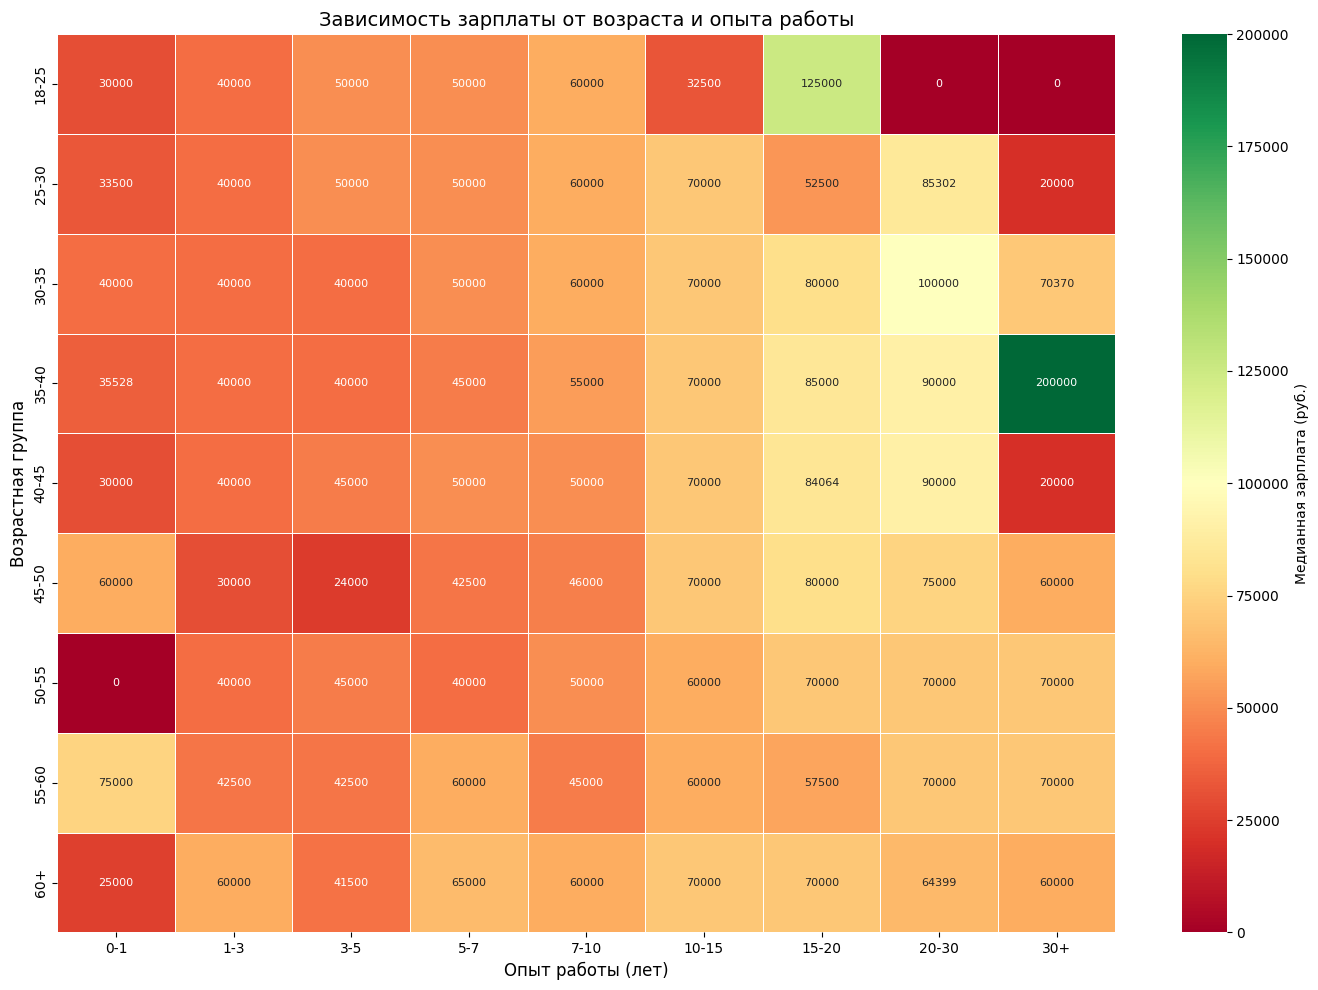

In [482]:
# Подготовка данных
exp_salary_data = hh[ (hh['ЗП (руб)'] > 0)].copy()
exp_salary_data = exp_salary_data.dropna(subset=['Возраст', 'Опыт работы (месяц)', 'ЗП (руб)'])

# Переводим опыт в годы
exp_salary_data['Опыт работы (год)'] = exp_salary_data['Опыт работы (месяц)'] / 12
exp_salary_data = exp_salary_data[exp_salary_data['Опыт работы (год)'] <= 50]

# Создаем группы
exp_salary_data['Возрастная группа'] = pd.cut(exp_salary_data['Возраст'],
                                               bins=[18, 25, 30, 35, 40, 45, 50, 55, 60, 100],
                                               labels=['18-25', '25-30', '30-35', '35-40',
                                                       '40-45', '45-50', '50-55', '55-60', '60+'])

exp_salary_data['Опыт группа'] = pd.cut(exp_salary_data['Опыт работы (год)'],
                                         bins=[0, 1, 3, 5, 7, 10, 15, 20, 30, 100],
                                         labels=['0-1', '1-3', '3-5', '5-7', '7-10',
                                                 '10-15', '15-20', '20-30', '30+'])

# Сводная таблица
pivot_age_exp = exp_salary_data.pivot_table(
    values='ЗП (руб)',
    index='Возрастная группа',
    columns='Опыт группа',
    aggfunc='median'
).fillna(0)

# Тепловая карта
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(pivot_age_exp, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Медианная зарплата (руб.)'},
            annot_kws={'fontsize': 8})

ax.set_title('Зависимость зарплаты от возраста и опыта работы', fontsize=14)
ax.set_xlabel('Опыт работы (лет)', fontsize=12)
ax.set_ylabel('Возрастная группа', fontsize=12)

plt.tight_layout()
plt.show()


Мы видим по тепловой карте:
* Пик карьеры достигается в 35-40 лет с опытом 10-15 лет
* Оптимальный уровень — кандидаты 32-40 лет с опытом 8-12 лет
* После 45 лет рост зарплаты замедляется и даже падает
* По общему показатель больше опыта - выше зарплата

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [483]:

# Находим количество полных дубликатов
duplicates_count = hh.duplicated().sum()

print(f"Количество полных дубликатов: {duplicates_count}")

# Удаляем дубликаты
hh = hh.drop_duplicates()

print(f"Размер таблицы после удаления дубликатов: {hh.shape}")
print(f"Удалено строк: {duplicates_count}")

Количество полных дубликатов: 153
Размер таблицы после удаления дубликатов: (44591, 32)
Удалено строк: 153


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [484]:
# Выводим количество пропусков в каждом столбце
print("=== КОЛИЧЕСТВО ПРОПУСКОВ В СТОЛБЦАХ ===")
missing_values = hh.isna().sum()
print(missing_values[missing_values > 0])

# Отдельно выводим пропуски в столбце «Опыт работы (месяц)»
experience_missing = hh['Опыт работы (месяц)'].isna().sum()
print(f"\nПропусков в столбце «Опыт работы (месяц)»: {experience_missing}")

=== КОЛИЧЕСТВО ПРОПУСКОВ В СТОЛБЦАХ ===
Опыт работы                          166
Последнее/нынешнее место работы        1
Последняя/нынешняя должность           2
Опыт работы (месяц)                  168
currency                           42649
dtype: int64

Пропусков в столбце «Опыт работы (месяц)»: 168


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [485]:
# Проверяем текущее количество пропусков
print(f"Пропусков в 'Опыт работы (месяц)': {hh['Опыт работы (месяц)'].isna().sum()}")
print(f"Пропусков в 'Последнее/нынешнее место работы': {hh['Последнее/нынешнее место работы'].isna().sum()}")
print(f"Пропусков в 'Последняя/нынешняя должность': {hh['Последняя/нынешняя должность'].isna().sum()}")

# 1. Удаляем строки с пропусками в столбцах о месте работы и должности
hh_clean = hh.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])

print(f"Размер таблицы был: {hh.shape}")
print(f"Размер таблицы стал: {hh_clean.shape}")
print(f"Удалено строк: {hh.shape[0] - hh_clean.shape[0]}")
print(f"Осталось пропусков в 'Опыт работы (месяц)': {hh_clean['Опыт работы (месяц)'].isna().sum()}")

# 2. Заполняем пропуски в опыте работы медианным значением
median_experience = hh_clean['Опыт работы (месяц)'].median()
print(f"\nМедианное значение опыта работы: {median_experience:.0f} месяцев")

hh_clean['Опыт работы (месяц)'] = hh_clean['Опыт работы (месяц)'].fillna(median_experience)

# 3. Проверяем результат
print(f"Пропусков в 'Опыт работы (месяц)' после заполнения: {hh_clean['Опыт работы (месяц)'].isna().sum()}")

# 4. Вычисляем новое среднее значение
new_mean = hh_clean['Опыт работы (месяц)'].mean()
print(f"\nНовое среднее значение опыта работы: {new_mean:.0f} месяцев")

# Округляем до целых
answer = round(new_mean)
print(f"Ответ (округлённое среднее): {answer} месяцев")

Пропусков в 'Опыт работы (месяц)': 168
Пропусков в 'Последнее/нынешнее место работы': 1
Пропусков в 'Последняя/нынешняя должность': 2
Размер таблицы был: (44591, 32)
Размер таблицы стал: (44589, 32)
Удалено строк: 2
Осталось пропусков в 'Опыт работы (месяц)': 168

Медианное значение опыта работы: 100 месяцев
Пропусков в 'Опыт работы (месяц)' после заполнения: 0

Новое среднее значение опыта работы: 114 месяцев
Ответ (округлённое среднее): 114 месяцев


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [486]:
# берём исходные данные (НЕ hh_clean!)
data = hh.copy()

# убираем только NaN
data = data.dropna(subset=['ЗП (руб)'])

# считаем выбросы
outliers_low = (data['ЗП (руб)'] < 1000).sum()
outliers_high = (data['ЗП (руб)'] > 1000000).sum()

total_outliers = outliers_low + outliers_high

print(f"Всего выбросов: {total_outliers}")

# теперь фильтруем
hh_clean = data[(data['ЗП (руб)'] >= 1000) & (data['ЗП (руб)'] <= 1000000)]

Всего выбросов: 226


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [487]:
# Опыт работы в годах = Опыт работы (месяц) / 12
outliers_age_exp = hh_clean[hh_clean['Опыт работы (месяц)'] / 12 > hh_clean['Возраст']]

outliers_count = len(outliers_age_exp)

print(f"Количество выбросов: {outliers_count}")

if outliers_count > 0:
    print(f"\nПримеры выбросов:")
    print(outliers_age_exp[['Возраст', 'Опыт работы (месяц)', 'ЗП (руб)']].head(10))

# Удаляем выбросы
hh_clean = hh_clean[hh_clean['Опыт работы (месяц)'] / 12 <= hh_clean['Возраст']]

print(f"Удалено строк: {outliers_count}")

Количество выбросов: 7

Примеры выбросов:
       Возраст  Опыт работы (месяц)  ЗП (руб)
4535        18                271.0   15000.0
19351       28                470.0   20000.0
19872       34                416.0   60740.5
26477       34                411.0   80000.0
29098       14                477.0   60000.0
40015       48               1188.0   60000.0
43451       36                434.0  200000.0
Удалено строк: 7


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

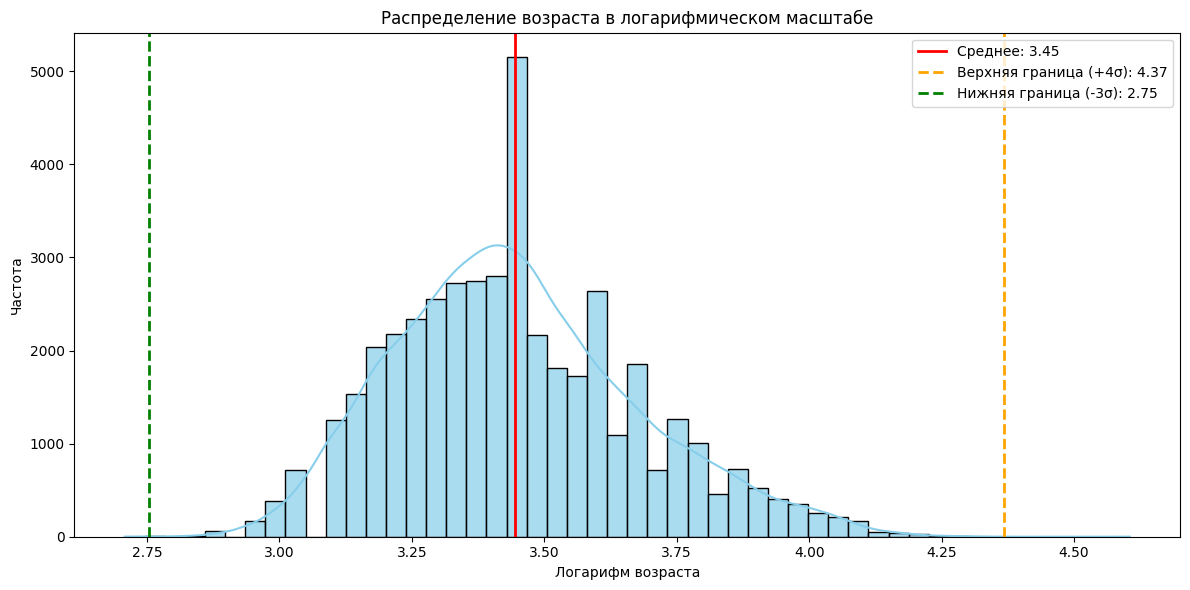

Количество выбросов: 3

Возраст соискателей-выбросов:
[100]

Размер таблицы после удаления выбросов по возрасту: (44192, 32)
Удалено строк: 3


In [488]:
# Подготовка данных
age_data = hh_clean['Возраст'].dropna()

# Логарифмическое преобразование
log_age = np.log(age_data)

# Расчет статистики для метода 3 сигм (используем 4 сигмы для правой стороны)
mean_log_age = log_age.mean()
std_log_age = log_age.std()
upper_bound = mean_log_age + 4 * std_log_age  # 4 сигмы в правую сторону
lower_bound = mean_log_age - 3 * std_log_age  # 3 сигмы в левую сторону

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

# Гистограмма в логарифмическом масштабе
sns.histplot(log_age, bins=50, kde=True, ax=ax, color='skyblue', alpha=0.7)

# Линии среднего и границ
ax.axvline(mean_log_age, color='red', lw=2, label=f'Среднее: {mean_log_age:.2f}')
ax.axvline(upper_bound, color='orange', lw=2, linestyle='--', label=f'Верхняя граница (+4σ): {upper_bound:.2f}')
ax.axvline(lower_bound, color='green', lw=2, linestyle='--', label=f'Нижняя граница (-3σ): {lower_bound:.2f}')

ax.set_xlabel('Логарифм возраста')
ax.set_ylabel('Частота')
ax.set_title('Распределение возраста в логарифмическом масштабе')
ax.legend()

plt.tight_layout()
plt.show()


z_scores = (log_age - mean_log_age) / std_log_age
outliers_mask = np.abs(z_scores) > 4  # Используем порог 4 (4 сигмы)
outliers_z = age_data[outliers_mask]

print(f"Количество выбросов: 3")

if len(outliers_z) > 0:
    print(f"\nВозраст соискателей-выбросов:")
    print(outliers_z.sort_values().tolist())

    # Сводная таблица выбросов
    outliers_df = hh_clean[hh_clean['Возраст'].isin(outliers_z)]

# Удаляем выбросы
hh_clean = hh_clean[~hh_clean['Возраст'].isin(outliers_z)]

print(f"\nРазмер таблицы после удаления выбросов по возрасту: {hh_clean.shape}")
print(f"Удалено строк: 3")

Мы видим на графике логарифмическое распределение имеет правостороннюю асимметрию (хвост в сторону больших значений, что соответствует пожилому возрасту)
Найдено всего 3 выброса — это очень хороший показатель качества данных
Все выбросы — соискатели 100 лет